## Unemployment Analysis with Python

**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

**Feature Checklist:**
- Download a suitable dataset (see Self-Sourcing Guideline below)
- Data loading, shape inspection, null value check, and type conversion
- EDA: region-wise average unemployment rates, month-wise trends
- Time-series line chart: unemployment rate over time for at least 3 major states/regions
- Bar chart: top 10 states with highest average unemployment rate
- Heatmap: correlation between unemployment rate, employment rate, and labour participation rate
- Pre-COVID vs. post-COVID comparison (split data by date, calculate mean rates for each period)
- Written observations/markdown cells between each chart explaining what the data shows
- Clean, well-commented Jupyter Notebook

#### IMPORT THE LIBRARIES

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

#### LOAD DATASET

In [2]:
# Load The Dataset
ua = pd.read_csv("Unemployment in India.csv")

In [3]:
# Check the first five rows of the dataset
ua.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# Check the last five rows of the dataset
ua.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### DATA CLEANING AND INVESTIGATION

In [5]:
# Check the important information of the dataset set
ua.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [6]:
# Checking columns names. Discovered the columns have space in them.
ua.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [7]:
# Clean column names that have unnecessary leading spaces
ua.columns = ua.columns.str.strip()
ua.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [8]:
# The 'Date' column is identified as 'string'. Convert to 'Datetime'
ua['Date'] = pd.to_datetime(ua['Date'], dayfirst=True)
ua.dtypes

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

In [9]:
# Going through the statistical values in the dataset 
ua.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [10]:
# Check the shape of the dataset
ua.shape

(768, 7)

In [11]:
# Check the null values of the dataset
ua.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [12]:
# Checking if the missing values are concentrated in particular states, dates or areas
ua[ua.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaT,NaN,NaN,NaN,NaN,NaN
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN
365,NaN,NaT,NaN,NaN,NaN,NaN,NaN
366,NaN,NaT,NaN,NaN,NaN,NaN,NaN
367,NaN,NaT,NaN,NaN,NaN,NaN,NaN
368,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [13]:
# Removing the rows where the missing values are located
ua.dropna(how='all', inplace=True)
ua.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [14]:
# Check the unique values for the three categorical features
print("Regions:")
print(ua['Region'].unique())

print("\nFrequency:")
print(ua['Frequency'].unique())

print("\nArea:")
print(ua['Area'].unique())

Regions:
<ArrowStringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str

Frequency:
<ArrowStringArray>
[' Monthly', 'Monthly']
Length: 2, dtype: str

Area:
<ArrowStringArray>
['Rural', 'Urban']
Length: 2, dtype: str


In [15]:
# Checking for duplicate values
ua.duplicated().sum()

np.int64(0)

### EXPLORATORY DATA ANALYSIS

#### Region-Wise Average Unemployment Rates

In [16]:
# Region Wise Average Unemployment Rates
region_avg = (
    ua.groupby('Region')['Estimated Unemployment Rate (%)'] .mean() .sort_values(ascending=False) .reset_index())
region_avg

,Region,Estimated Unemployment Rate (%)
0,Tripura,28.350357
1,Haryana,26.283214
2,Jharkhand,20.585000
3,Bihar,18.918214
4,Himachal Pradesh,18.540357
5,Delhi,16.495357
6,Jammu & Kashmir,16.188571
7,Chandigarh,15.991667
8,Rajasthan,14.058214
9,Uttar Pradesh,12.551429


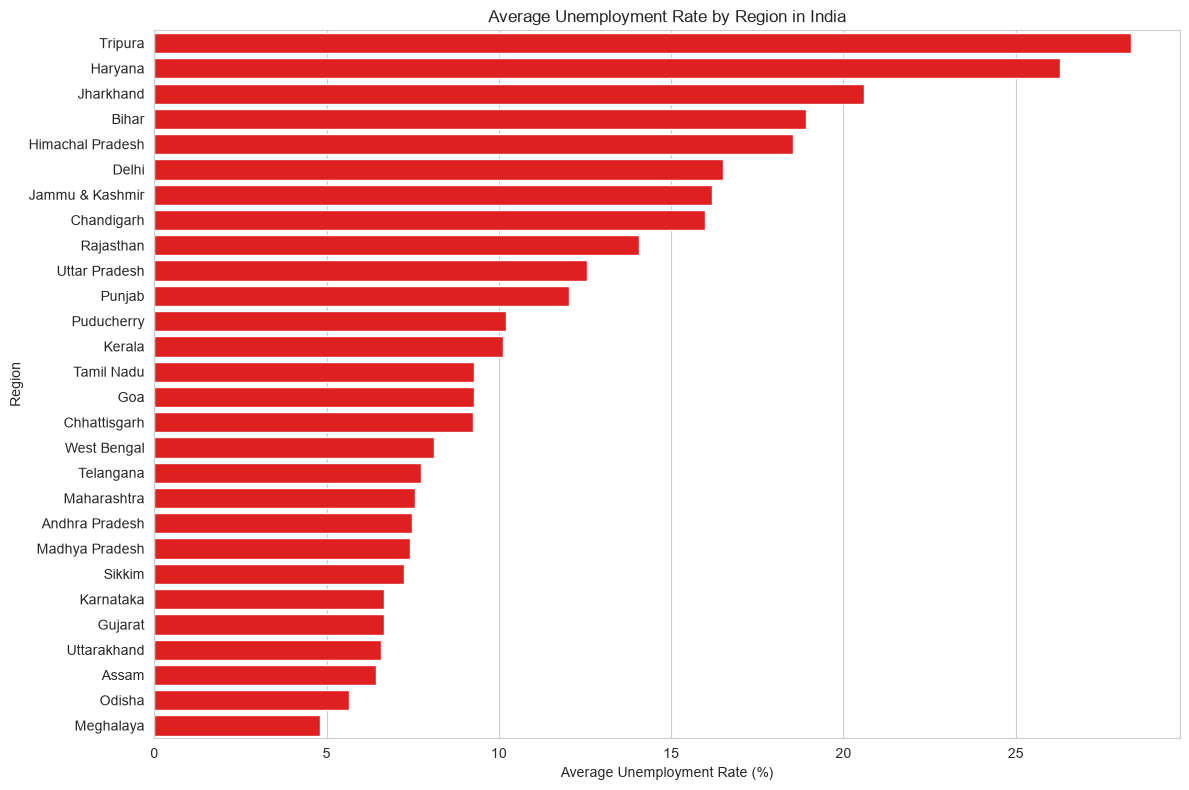

In [17]:
# Visualization of the Region Wise Average Unemployment Rates
plt.figure(figsize=(12, 8))
sns.barplot(data=region_avg, x='Estimated Unemployment Rate (%)', y='Region', color='red')
plt.title('Average Unemployment Rate by Region in India')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

#### Month-Wise Trends

In [18]:
# Create a 'Year_Month' variable for better analysis
ua['Year_Month'] = ua['Date'].dt.to_period('M')

In [19]:
# Calculate the average unemployment rate for every month
monthly_avg = (ua.groupby('Year_Month')['Estimated Unemployment Rate (%)'].mean().reset_index())
monthly_avg

,Year_Month,Estimated Unemployment Rate (%)
0,2019-05,8.874259
1,2019-06,9.303333
2,2019-07,9.033889
3,2019-08,9.637925
4,2019-09,9.051731
5,2019-10,9.900909
6,2019-11,9.868364
7,2019-12,9.497358
8,2020-01,9.950755
9,2020-02,9.964717


In [20]:
# Convert Year_Month to a string for easy plotting
monthly_avg['Year_Month'] = monthly_avg['Year_Month'].astype(str)

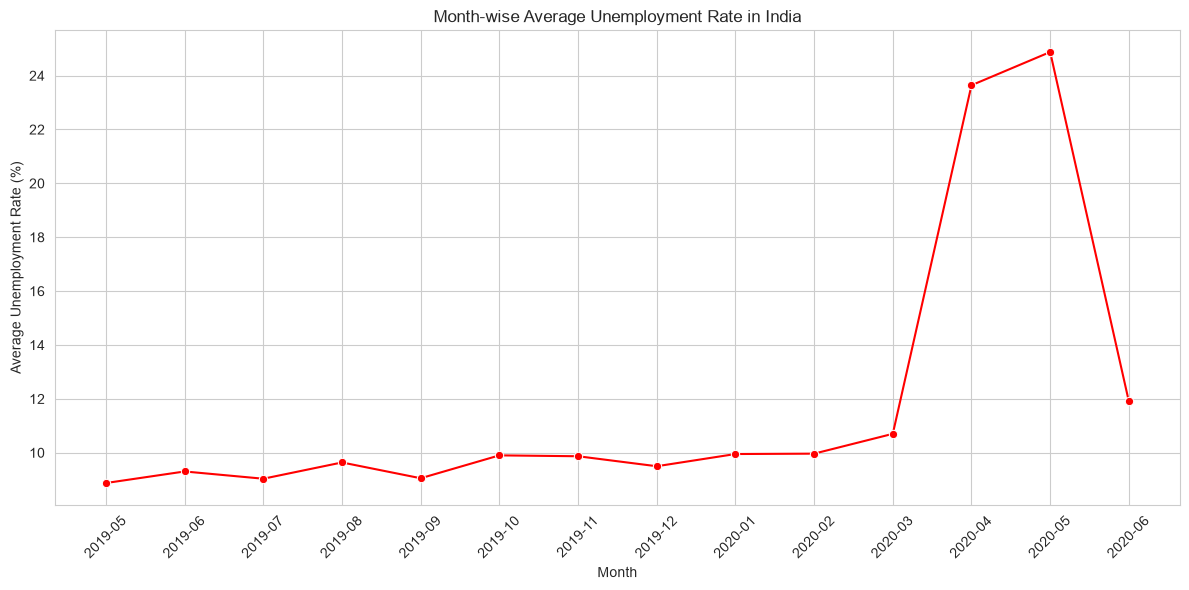

In [21]:
# Visualization of the Month Wise Trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x='Year_Month', y='Estimated Unemployment Rate (%)', marker='o', color= 'red')
plt.title('Month-wise Average Unemployment Rate in India')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Time-Series Line Chart: Unemployment Rate Over Time For At Least 3 Major States/Regions

In [22]:
# Selecting the three states. The dataset contains both Rural and urban observations.
selected_states = ['Tripura', 'Haryana', 'Maharashtra']
state_data = ua[ua['Region'].isin(selected_states)]
state_data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year_Month
94,Haryana,2019-05-31,Monthly,14.54,5249186.0,45.12,Rural,2019-05
95,Haryana,2019-06-30,Monthly,23.08,4745178.0,45.23,Rural,2019-06
96,Haryana,2019-07-31,Monthly,16.22,4826560.0,42.17,Rural,2019-07
97,Haryana,2019-08-31,Monthly,30.94,4558306.0,48.23,Rural,2019-08
98,Haryana,2019-09-30,Monthly,16.36,5127956.0,44.72,Rural,2019-09


In [23]:
# Since the dataset contains both Rural and urban observations,
# therefore, plotting the raw rows directly may produce multiple 
# observations for the same state and month. 
# I had to calculate the monthly average unemployment rate for each state first,
# which gives us one average unemployment rate for each selected state at each date.
state_monthly = (state_data.groupby(['Region', 'Date'])['Estimated Unemployment Rate (%)'].mean().reset_index())
state_monthly.head()

,Region,Date,Estimated Unemployment Rate (%)
0,Haryana,2019-05-31,19.605
1,Haryana,2019-06-30,21.750
2,Haryana,2019-07-31,20.835
3,Haryana,2019-08-31,27.565
4,Haryana,2019-09-30,21.600


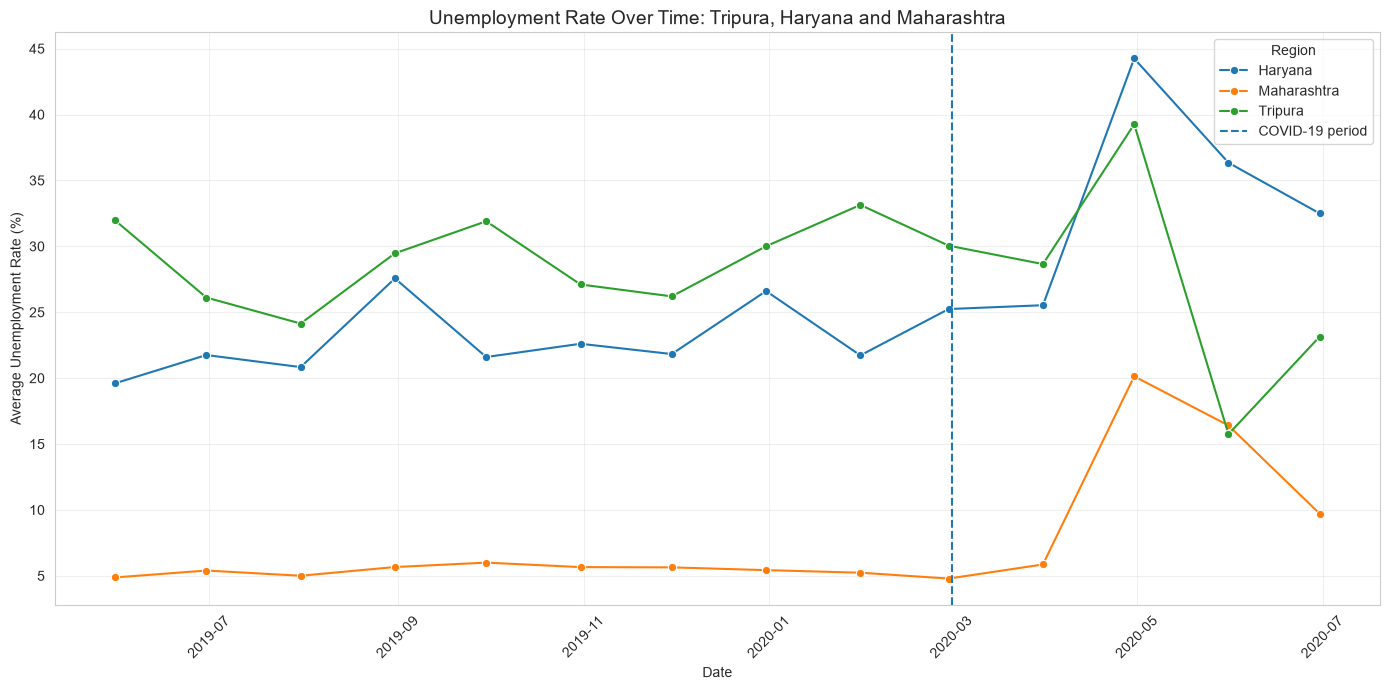

In [24]:
# Create the Time-Series Line Chart: unemployment rate over time for at least 3 major states/regions
# This also highlight the beginning of the major COVID-19 disruption with a vertical line:
plt.figure(figsize=(14, 7))
sns.lineplot(data=state_monthly, x='Date', y='Estimated Unemployment Rate (%)',hue='Region', marker='o')
plt.axvline(pd.Timestamp('2020-03-01'), linestyle='--', label='COVID-19 period')
plt.title('Unemployment Rate Over Time: Tripura, Haryana and Maharashtra', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Bar Chart: Top 10 States With Highest Average Unemployment Rate

In [25]:
# Select the top 10 states/regions
top_10_states = region_avg.head(10)

# Display the result
top_10_states

,Region,Estimated Unemployment Rate (%)
0,Tripura,28.350357
1,Haryana,26.283214
2,Jharkhand,20.585000
3,Bihar,18.918214
4,Himachal Pradesh,18.540357
5,Delhi,16.495357
6,Jammu & Kashmir,16.188571
7,Chandigarh,15.991667
8,Rajasthan,14.058214
9,Uttar Pradesh,12.551429


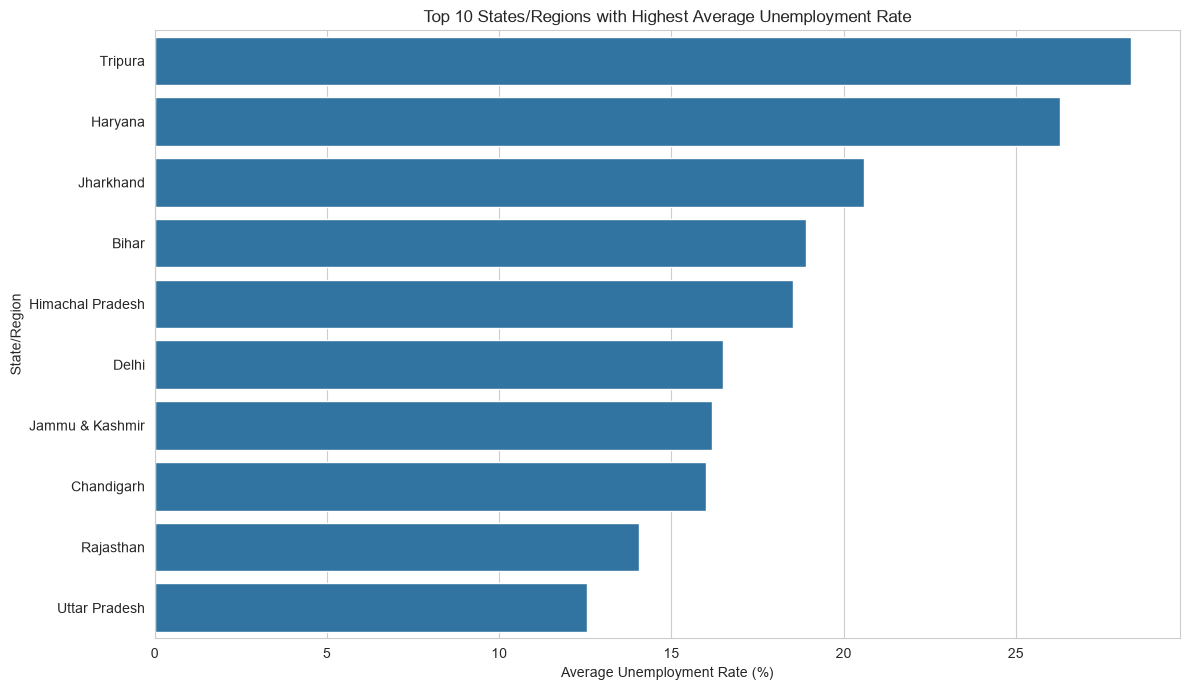

In [26]:
# The Horizontal Bar Chart: top 10 states with highest average unemployment rate
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_states, x='Estimated Unemployment Rate (%)', y='Region')
plt.title('Top 10 States/Regions with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State/Region')
plt.tight_layout()
plt.show()

- The bar chart shows considerable variation in average unemployment rates among the ten highest-ranked states and regions. 
- Tripura recorded the highest average unemployment rate at approximately 28.35%, followed closely by Haryana at 26.28%.
- Jharkhand ranked third with 20.59%, while Bihar and Himachal Pradesh recorded 18.92% and 18.54%, respectively.
- Uttar Pradesh ranked tenth with an average unemployment rate of 12.55%.
- Overall, Tripura and Haryana stand out as having substantially higher average unemployment rates than most of the other regions in the top ten.

#### Heatmap: Correlation Between Unemployment Rate, Employment Rate, And Labour Participation Rate

In [38]:
# select the three numerical variables
correlation_data = ua[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

In [28]:
# Calculate the Pearson correlation matrix
correlation_matrix = correlation_data.corr()
correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


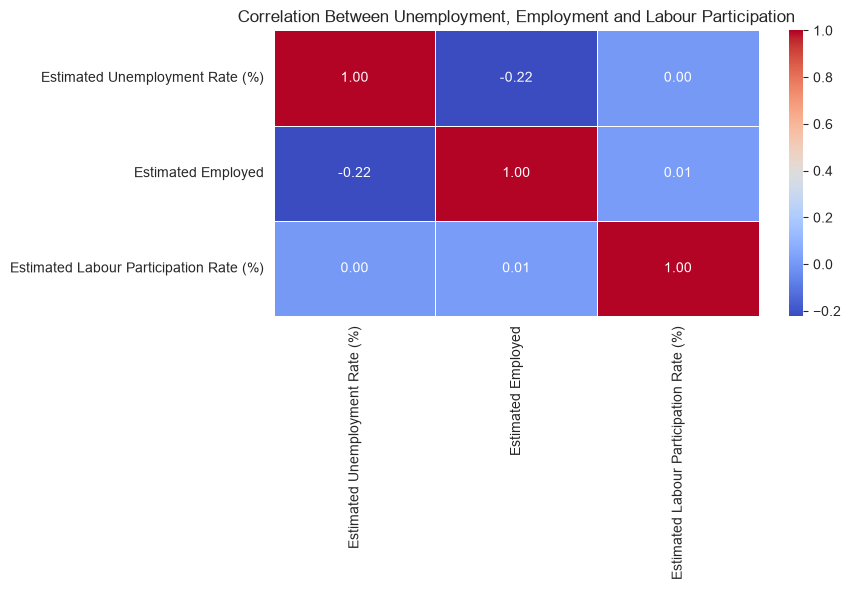

In [29]:
# Heatma: correlation between unemployment rate, employment rate, and labour participation rate
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Unemployment, Employment and Labour Participation')
plt.tight_layout()
plt.show()

- The correlation heatmap shows a weak negative relationship between the estimated unemployment rate and estimated employed population, with a correlation coefficient of approximately -0.22.
- The estimated unemployment rate has an almost zero correlation with the estimated labour participation rate, at approximately 0.003.
- Similarly, the relationship between estimated employed population and labour participation rate is extremely weak, with a correlation coefficient of approximately 0.01.


#### Pre-COVID vs. Post-COVID Comparison (split data by date, calculate mean rates for each period

In [30]:
# Split observations into Pre-COVID and Post-COVID by creating a "Period" variable
ua['Period'] = ua['Date'].apply(
    lambda date: 'Pre-COVID' if date < pd.Timestamp('2020-03-01')
    else 'Post-COVID'
)

ua[['Date', 'Period']].head()

,Date,Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID


In [31]:
# Verify the classification
ua.groupby('Period')['Date'].agg(['min', 'max', 'count'])

,min,max,count
Period,,,
Post-COVID,2020-03-31,2020-06-30,204
Pre-COVID,2019-05-31,2020-02-29,536


In [32]:
# Calculate Mean Unemployment Rate for the two period
period_avg = (ua.groupby('Period')['Estimated Unemployment Rate (%)'].mean().reset_index())
period_avg

,Period,Estimated Unemployment Rate (%)
0,Post-COVID,17.774363
1,Pre-COVID,9.509534


In [33]:
# Calculate and verify all three Labour-Market Measures
period_comparison = (ua.groupby('Period').agg({
          'Estimated Unemployment Rate (%)': 'mean',
          'Estimated Employed': 'mean',
          'Estimated Labour Participation Rate (%)': 'mean'}).round(2))
period_comparison

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,
Post-COVID,17.77,6517203.34,39.33
Pre-COVID,9.51,7466027.87,43.89


In [34]:
# Calculate and quantify the Change in Unemployment
pre_covid_mean = ua.loc[ua['Period'] == 'Pre-COVID', 'Estimated Unemployment Rate (%)'].mean()
post_covid_mean = ua.loc[ua['Period'] == 'Post-COVID', 'Estimated Unemployment Rate (%)'].mean()
difference = post_covid_mean - pre_covid_mean
percentage_change = ((post_covid_mean - pre_covid_mean) / pre_covid_mean) * 100

print(f"Pre-COVID Mean: {pre_covid_mean:.2f}%")
print(f"Post-COVID Mean: {post_covid_mean:.2f}%")
print(f"Increase: {difference:.2f} percentage points")
print(f"Relative Increase: {percentage_change:.2f}%")

Pre-COVID Mean: 9.51%
Post-COVID Mean: 17.77%
Increase: 8.26 percentage points
Relative Increase: 86.91%


- The comparison reveals a substantial deterioration in labour-market indicators during the COVID-19 period.
- The average unemployment rate increased from approximately 9.51% during the pre-COVID period to 17.77% during the COVID-19 period, representing an increase of 8.26 percentage points.
- The Relative Increase is 86.91%

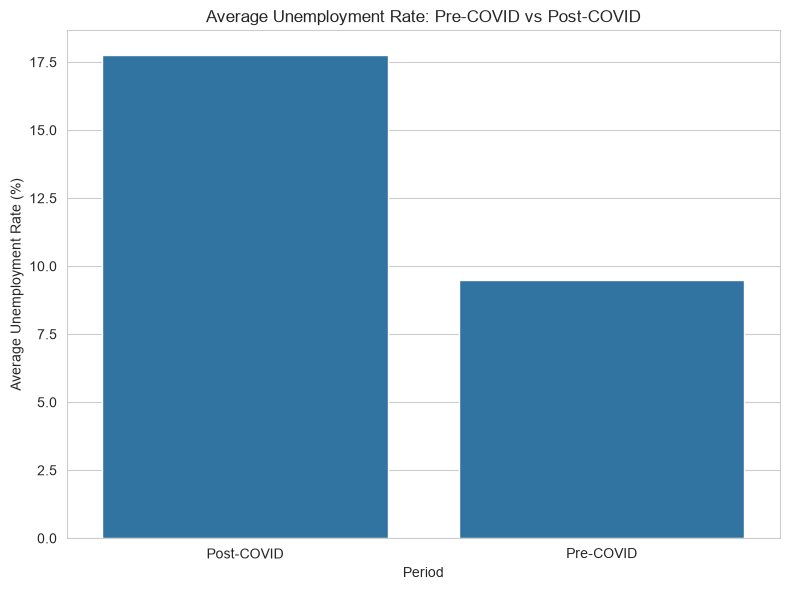

In [35]:
plt.figure(figsize=(8, 6))
sns.barplot(data=period_avg, x='Period', y='Estimated Unemployment Rate (%)')
plt.title('Average Unemployment Rate: Pre-COVID vs Post-COVID')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

- The comparison reveals a substantial deterioration in labour-market indicators during the COVID-19 period.
- The average unemployment rate increased from approximately 9.51% during the pre-COVID period to 17.77% during the COVID-19 period, representing an increase of 8.26 percentage points.
- The results indicate a significant labour-market disruption during the COVID-19 period. The average unemployment rate increased by approximately 86.9% relative to the pre-COVID average.
- Taken together, these patterns suggest that the COVID-19 period was associated not only with higher unemployment but also with lower employment and reduced participation in the labour force. This provides evidence of broad labour-market disruption during the period covered by the dataset.

- The Pre-COVID and Post-COVID comparison demonstrates a pronounced change in India's labour-market conditions. Average unemployment increased from 9.51% to 17.77%, while average estimated employment and labour participation both declined.
- These findings are consistent with the temporal analysis, which showed a sharp rise in unemployment during April and May 2020.
- Overall, the analysis indicates that the early COVID-19 period coincided with a substantial negative shock to employment conditions in India.
